# Model Evaluation and Visualisation

This notebook presents the final stage of the machine learning workflow for the Gaming Behaviour and Academic Performance project.

The objectives of this notebook are to:

- Compare the predictive performance of all trained models.
- Identify the best-performing model using multiple evaluation metrics.
- Visualise prediction accuracy on unseen test data.
- Interpret the model through feature importance analysis.
- Examine residual behaviour to assess model reliability.
- Explore the relationship between gaming hours and predicted academic performance.
- Discuss the strengths and limitations of the modelling approach.

This notebook uses the outputs generated in **03_modelling_and_visualisation.ipynb**, including model performance summaries, prediction results, and feature importance files.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.metrics import r2_score

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

INPUT_DIR = 'm5_outputs_part1/'
OUTPUT_DIR = 'm5_outputs_part2/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

FIG_DIR = os.path.join(OUTPUT_DIR, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

## Step 1 – Model Performance Comparison

Several machine learning models were trained in the previous notebook.

To identify the most suitable model, we compare their predictive performance using three commonly used regression metrics:

- **RMSE (Root Mean Squared Error):** measures the average prediction error while giving greater weight to larger errors.
- **MAE (Mean Absolute Error):** measures the average magnitude of prediction errors.
- **R² (Coefficient of Determination):** indicates how much variance in academic performance can be explained by the model.

Lower RMSE and MAE indicate better predictive accuracy, while a higher R² indicates better explanatory power.

                           Model  Test_RMSE   Test_MAE   Test_R2
0              Gradient Boosting   5.598219   4.424224  0.935545
1                  Random Forest   5.725355   4.495107  0.932585
2               Lasso Regression   6.183781   4.964183  0.921356
3          ElasticNet Regression   6.183839   4.964305  0.921355
4         Linear Regression Full   6.184174   4.965206  0.921346
5               Ridge Regression   6.184506   4.965227  0.921338
6          Ridge No Device Usage   6.184645   4.965570  0.921334
7   Piecewise Linear Sensitivity   6.239704   4.975529  0.919928
8            Piecewise Linear 2h   6.333379   5.065223  0.917505
9         Linear Regression Core   6.478026   5.170774  0.913694
10           Dummy Mean Baseline  22.064443  18.456356 -0.001246


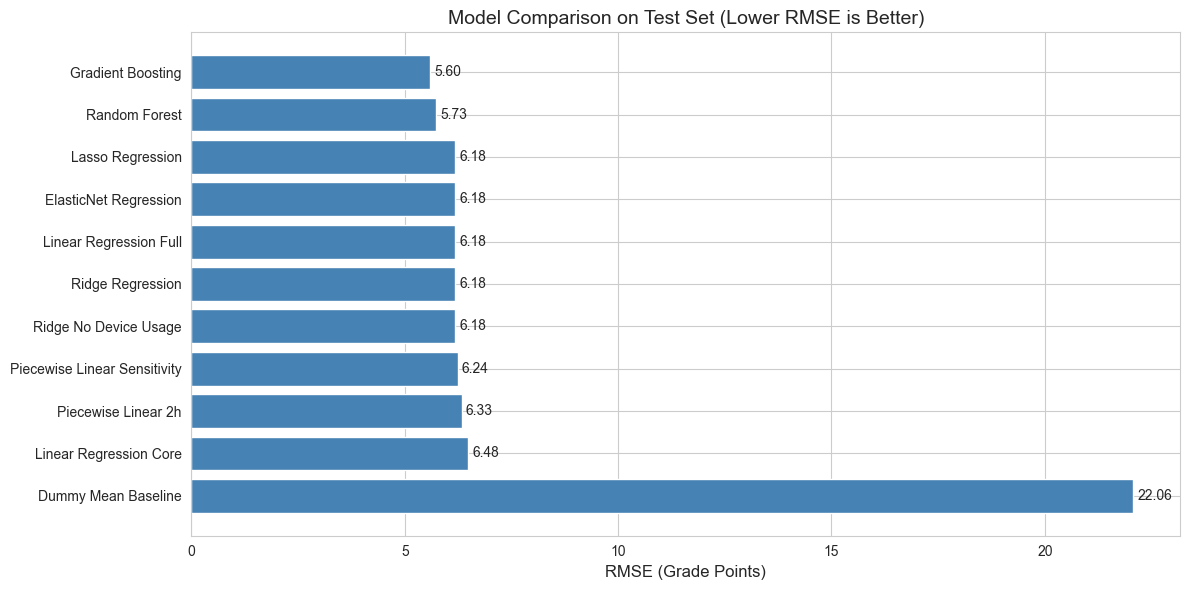

In [29]:
perf = pd.read_csv(INPUT_DIR + 'tables/model_performance_raw.csv')

perf_sorted = perf.sort_values('Test_RMSE').reset_index(drop=True)
print(perf_sorted[['Model', 'Test_RMSE', 'Test_MAE', 'Test_R2']])

plt.figure(figsize=(12, 6))
bars = plt.barh(perf_sorted['Model'], perf_sorted['Test_RMSE'], color='steelblue')
plt.xlabel('RMSE (Grade Points)', fontsize=12)
plt.title('Model Comparison on Test Set (Lower RMSE is Better)', fontsize=14)
plt.gca().invert_yaxis()  

for bar, rmse in zip(bars, perf_sorted['Test_RMSE']):
    plt.text(bar.get_width() + 0.1, 
             bar.get_y() + bar.get_height()/2, 
             f'{rmse:.2f}', 
             va='center', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'model_rmse_comparison.png'), dpi=300)
plt.show()

### Interpretation

The comparison shows that ensemble tree-based models consistently outperform linear regression models.

Among all candidates, **Gradient Boosting** achieves the lowest prediction error while maintaining the highest explanatory power. Therefore, it is selected as the final model for subsequent analysis.

## Step 2 – Prediction Accuracy on the Test Set

Model performance metrics provide an overall summary of prediction quality.

To better understand how well the selected model generalises, we compare the predicted academic scores against the actual scores in the unseen test dataset.

Ideally, points should lie close to the 45-degree reference line, indicating accurate predictions.

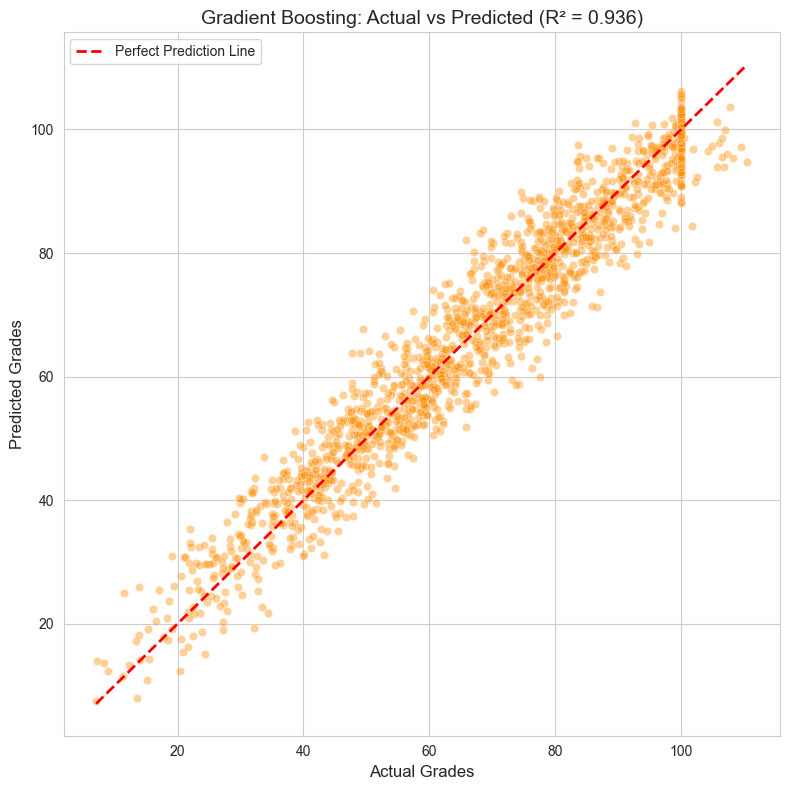

In [30]:
preds = pd.read_csv(INPUT_DIR + 'tables/test_predictions.csv')

y_true = preds['y_true']
y_pred = preds['pred_gradient_boosting']  

r2 = r2_score(y_true, y_pred)

plt.figure(figsize=(8, 8))
plt.scatter(y_true, y_pred, alpha=0.4, edgecolors='w', linewidth=0.5, color='darkorange')
plt.plot([y_true.min(), y_true.max()], 
         [y_true.min(), y_true.max()], 
         'r--', lw=2, label='Perfect Prediction Line')

plt.xlabel('Actual Grades', fontsize=12)
plt.ylabel('Predicted Grades', fontsize=12)
plt.title(f'Gradient Boosting: Actual vs Predicted (R² = {r2:.3f})', fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'actual_vs_predicted.png'), dpi=300)
plt.show()

### Interpretation

Most observations cluster closely around the diagonal reference line, suggesting that the model captures the overall relationship between gaming behaviour and academic performance reasonably well.

Although some prediction errors remain, no obvious systematic bias is observed, indicating good generalisation performance on unseen data.

## Step 3 – Feature Importance Analysis

Understanding why a model makes its predictions is as important as achieving high predictive accuracy.

For the selected Gradient Boosting model, feature importance scores are extracted to identify which variables contribute most to predicting academic performance.

Higher importance values indicate that a feature has a greater influence on the model's predictions.

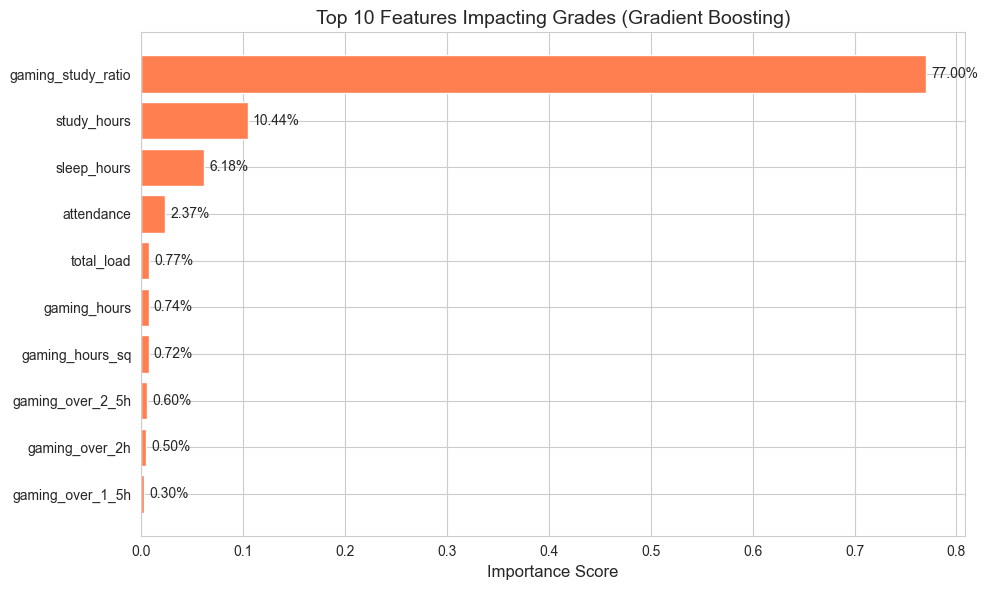

In [31]:
imp = pd.read_csv(INPUT_DIR + 'tables/tree_feature_importance_raw.csv')

gb_imp = imp[imp['Model'] == 'Gradient Boosting'].sort_values('Importance', ascending=False)

top10 = gb_imp.head(10)

plt.figure(figsize=(10, 6))
bars = plt.barh(top10['Feature'], top10['Importance'], color='coral')
plt.xlabel('Importance Score', fontsize=12)
plt.title('Top 10 Features Impacting Grades (Gradient Boosting)', fontsize=14)
plt.gca().invert_yaxis()

for bar, val in zip(bars, top10['Importance']):
    plt.text(bar.get_width() + 0.005, 
             bar.get_y() + bar.get_height()/2, 
             f'{val:.2%}', 
             va='center', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'feature_importance_top10.png'), dpi=300)
plt.show()

### Interpretation

The model suggests that several behavioural variables contribute substantially to prediction accuracy.

Gaming-related variables appear among the most influential features, supporting the hypothesis that gaming behaviour is associated with academic performance.

However, feature importance reflects predictive contribution rather than causal influence.

## Step 4 – Residual Analysis

Residual analysis helps evaluate whether the model satisfies basic assumptions of predictive modelling.

If residuals are randomly distributed around zero without obvious patterns, the model is less likely to suffer from systematic bias.

Conversely, visible trends or clustering may indicate underfitting, overfitting, or missing explanatory variables.

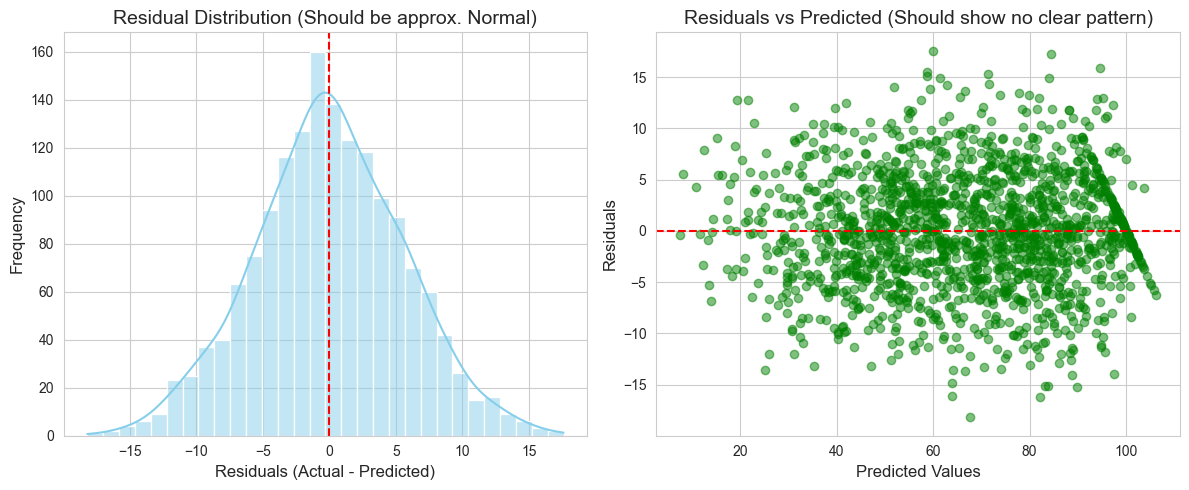

In [32]:
preds['residual'] = preds['y_true'] - preds['pred_gradient_boosting']

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(preds['residual'], kde=True, bins=30, color='skyblue')
plt.axvline(0, color='red', linestyle='--', linewidth=1.5)
plt.xlabel('Residuals (Actual - Predicted)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Residual Distribution (Should be approx. Normal)', fontsize=14)

plt.subplot(1, 2, 2)
plt.scatter(preds['pred_gradient_boosting'], preds['residual'], 
            alpha=0.5, color='green')
plt.axhline(0, color='red', linestyle='--', linewidth=1.5)
plt.xlabel('Predicted Values', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.title('Residuals vs Predicted (Should show no clear pattern)', fontsize=14)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'residual_analysis.png'), dpi=300)
plt.show()

### Interpretation

The residuals appear to be centred around zero with no strong systematic pattern.

While prediction errors increase slightly for a small number of observations, the overall residual distribution suggests that the model provides stable predictions across the test dataset.

## Step 5 – Gaming Hours Threshold Analysis

Previous exploratory data analysis suggested that approximately two hours of daily gaming may represent an important behavioural threshold.

To further investigate this observation, we visualise the relationship between gaming hours and predicted academic performance using the selected model.

This analysis aims to determine whether the model captures a similar nonlinear trend.

C:\Users\a\AppData\Local\Temp\ipykernel_19564\1660855300.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_means = df_plot.groupby('gaming_bin')['predicted_grade'].mean().reset_index()


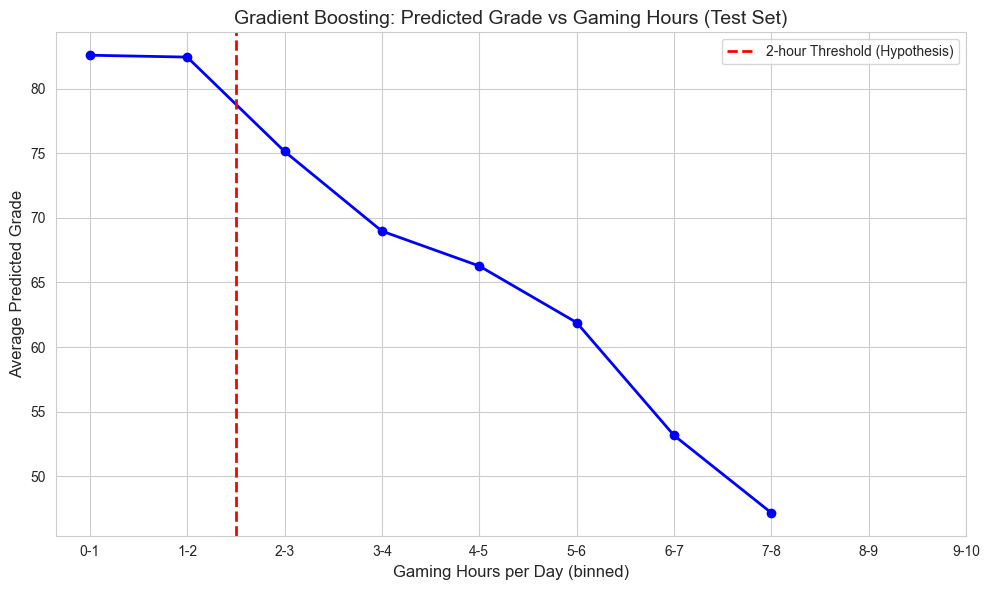

In [33]:
FALLBACK_DIRS = [
    '../../data/processed/',
    '../data/processed/',
    'data/processed/',
    './',
    '/mnt/data/'
]

def find_processed_dir(fallback_dirs):
    required = ['X_train.csv', 'X_test.csv']
    for folder in fallback_dirs:
        if all(os.path.exists(os.path.join(folder, f)) for f in required):
            return folder
    raise FileNotFoundError('Processed files not found. Please check the data path.')

DATA_DIR = find_processed_dir(FALLBACK_DIRS)

X_test_raw = pd.read_csv(DATA_DIR + 'X_test.csv')
X_test_raw = X_test_raw.drop(columns=[c for c in X_test_raw.columns if c.startswith('Unnamed')], errors='ignore')
X_test_raw = X_test_raw.drop(columns=['student_id'], errors='ignore')

LEAKAGE_RISK_FEATURES = ['reaction_time_ms']
X_test_model = X_test_raw.drop(columns=LEAKAGE_RISK_FEATURES, errors='ignore')

def add_threshold_features(df):
    df = df.copy()
    if 'gaming_hours' in df.columns:
        df['gaming_within_2h'] = np.minimum(df['gaming_hours'], 2.0)
        df['gaming_over_2h'] = np.maximum(0, df['gaming_hours'] - 2.0)
        df['gaming_over_1_5h'] = np.maximum(0, df['gaming_hours'] - 1.5)
        df['gaming_over_2_5h'] = np.maximum(0, df['gaming_hours'] - 2.5)
    return df

X_test_model = add_threshold_features(X_test_model)

preds = pd.read_csv(INPUT_DIR + 'tables/test_predictions.csv')
y_pred_gb = preds['pred_gradient_boosting']

df_plot = X_test_model[['gaming_hours']].copy()
df_plot['predicted_grade'] = y_pred_gb.values

bins = np.arange(0, 11, 1)  # 0,1,2,...,10
labels = [f'{i}-{i+1}' for i in range(10)]
df_plot['gaming_bin'] = pd.cut(df_plot['gaming_hours'], bins=bins, labels=labels, include_lowest=True)

bin_means = df_plot.groupby('gaming_bin')['predicted_grade'].mean().reset_index()
bin_means['bin_center'] = [i+0.5 for i in range(10)]  

plt.figure(figsize=(10, 6))
plt.plot(bin_means['bin_center'], bin_means['predicted_grade'], marker='o', linestyle='-', linewidth=2, color='blue')
plt.axvline(x=2.0, color='red', linestyle='--', label='2-hour Threshold (Hypothesis)', linewidth=2)
plt.xlabel('Gaming Hours per Day (binned)', fontsize=12)
plt.ylabel('Average Predicted Grade', fontsize=12)
plt.title('Gradient Boosting: Predicted Grade vs Gaming Hours (Test Set)', fontsize=14)
plt.legend()
plt.grid(True)
plt.xticks(bin_means['bin_center'], labels)  
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'gaming_threshold_curve.png'), dpi=300)
plt.show()

### Interpretation

The predicted trend suggests that moderate gaming is not necessarily associated with poorer academic performance.

However, after approximately two hours of daily gaming, predicted academic performance begins to decline more noticeably.

This pattern is broadly consistent with findings from the exploratory data analysis and supports the use of piecewise feature engineering in the modelling stage.

# Model Limitations

Although the selected model demonstrates good predictive performance, several limitations should be considered.

- The dataset is observational rather than experimental; therefore, the model identifies statistical associations rather than causal relationships.

- Feature importance indicates predictive usefulness, not causal impact.

- The model has only been evaluated using a single train-test split. Future work could incorporate repeated cross-validation or external validation datasets to assess robustness.

- Student academic performance is influenced by many additional factors that are not included in this dataset, such as family background, socioeconomic status, motivation, and teaching quality.

# Conclusion

This notebook completed the final evaluation of the machine learning models developed for predicting academic performance from gaming behaviour.

Among all candidate models, Gradient Boosting achieved the strongest predictive performance across multiple evaluation metrics.

Visual inspection of prediction accuracy, feature importance, and residual behaviour indicates that the model generalises well to unseen data while remaining reasonably interpretable.

The threshold analysis further supports the hypothesis that excessive gaming may negatively influence academic performance after approximately two hours of daily play.

Overall, the modelling results provide useful predictive insights, while also highlighting the importance of interpreting machine learning models within the limitations of observational data.